# Monte Carlo size and power study

For four scenarios and four sample sizes, draw 1,000 replications, fit the AR(1)-GARCH(1,1)-t baseline on the first 60% of each path, and run the unified backtest battery on the remaining 40%. Report the empirical rejection rate of every test under H0 (correctly specified) and under three H1 alternatives: moderate GJR leverage (γ=0.15), strong GJR leverage (γ=0.25), and Normal-innovation distribution misspecification.

In [1]:

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from esback.config import REPO_ROOT
from esback.simulation.dgp import AR1GarchDGP, GjrGarchDGP
from esback.simulation.power_study import (
    Scenario,
    run_power_study,
    summarize_power,
)
from esback.viz import figures, style

style.apply_rcparams()
ASSETS_FIG = REPO_ROOT / "assets" / "figures"
RESULTS = REPO_ROOT / "results" / "power_study"
RESULTS.mkdir(parents=True, exist_ok=True)

scenarios = [
    Scenario(name="H0_garch_t", dgp=AR1GarchDGP(nu=8.0)),
    Scenario(name="H1_gjr_t", dgp=GjrGarchDGP(gamma=0.15, nu=8.0)),
    Scenario(name="H1_gjr_strong", dgp=GjrGarchDGP(gamma=0.25, nu=8.0)),
    Scenario(name="H1_normal", dgp=AR1GarchDGP(dist="normal")),
]
sample_sizes = [250, 500, 1000, 2500]
n_replications = 1000
len(scenarios), sample_sizes, n_replications

(4, [250, 500, 1000, 2500], 1000)

## Run the study with on-disk cache

Sixteen thousand replications take roughly twenty-five minutes on Apple Silicon (the inner fits are vectorised over numpy and arch). The result is cached in ``results/power_study/results.parquet`` so subsequent notebook runs are instantaneous.

In [2]:
cache_path = RESULTS / "results.parquet"

if cache_path.exists():
    raw = pd.read_parquet(cache_path)
    print(f"loaded cached study ({len(raw):,} rows)")
else:
    raw = run_power_study(
        scenarios,
        sample_sizes,
        n_replications=n_replications,
        in_sample_fraction=0.6,
        alpha_es=0.10,
        alpha_var=0.05,
        m=5,
        n_bootstrap=200,
        seed=42,
    )
    raw.to_parquet(cache_path)
    print(f"computed and cached study ({len(raw):,} rows)")

summary = summarize_power(raw, level=0.05)
summary.head()

[05/19/26 01:35:35] INFO       H0_garch_t @ n=250: 1000/16000 replications done

[05/19/26 01:36:23] INFO       H0_garch_t @ n=500: 2000/16000 replications done

[05/19/26 01:37:35] INFO       H0_garch_t @ n=1000: 3000/16000 replications done

[05/19/26 01:40:03] INFO       H0_garch_t @ n=2500: 4000/16000 replications done

[05/19/26 01:40:39] INFO       H1_gjr_t @ n=250: 5000/16000 replications done

...

[05/19/26 01:53:28] INFO       H1_normal @ n=500: 14000/16000 replications done

[05/19/26 01:55:15] INFO       H1_normal @ n=1000: 15000/16000 replications done

[05/19/26 01:59:19] INFO       H1_normal @ n=2500: 16000/16000 replications done

computed and cached study (176,000 rows)


,scenario,n,test,rejection_rate
0,H0_garch_t,250,AS_Z1,0.160
1,H0_garch_t,250,AS_Z2,0.224
2,H0_garch_t,250,C_ES(5),0.252
3,H0_garch_t,250,C_VaR(5),0.193
4,H0_garch_t,250,Christoffersen_CC,0.174


## Empirical size under H0

Under correct specification, every test should reject at ~5% as ``n`` grows. Tests that reject too often have inflated size; those that reject too rarely are conservative.

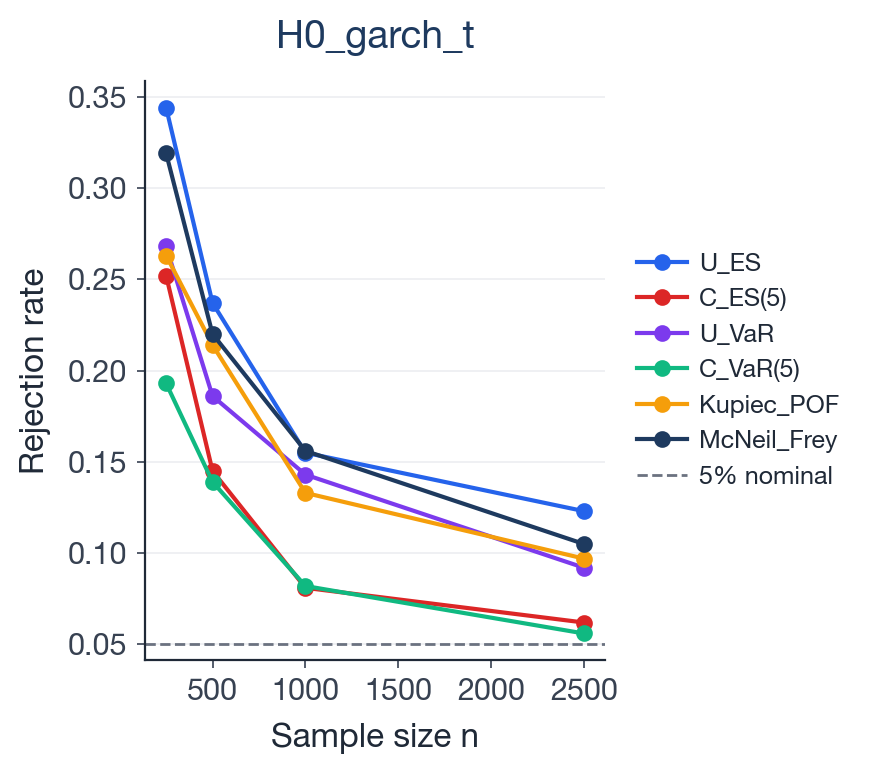

In [3]:
key_tests = ["U_ES", "C_ES(5)", "U_VaR", "C_VaR(5)", "Kupiec_POF", "McNeil_Frey"]

size_summary = summary[summary["scenario"] == "H0_garch_t"]
fig = figures.plot_power_curves(
    size_summary,
    key_tests,
    save_to=ASSETS_FIG / "03_size_under_h0.png",
)
plt.show()

## Power against three alternatives

- **H1_gjr_t**: asymmetric GJR-GARCH(1,1,1)-t with ``gamma = 0.15`` (moderate leverage; rejection rates at n=1000 stay under 25 % for all tests, cf. CODE #9 below).
- **H1_gjr_strong**: asymmetric GJR-GARCH(1,1,1)-t with ``gamma = 0.25`` (strong leverage; the symmetric AR(1)-GARCH(1,1)-t fit is materially misspecified and the rejection regime is reached for the marginal-coverage tests, with ``U_ES``, ``U_VaR``, ``Kupiec_POF``, ``KLM_multinomial(4)``, and ``Christoffersen_CC`` reaching 28-39 % at n=1000).
- **H1_normal**: data come from AR(1)-GARCH(1,1)-Normal; the claimed model is AR(1)-GARCH(1,1)-t, mis-specifying the tail thickness.

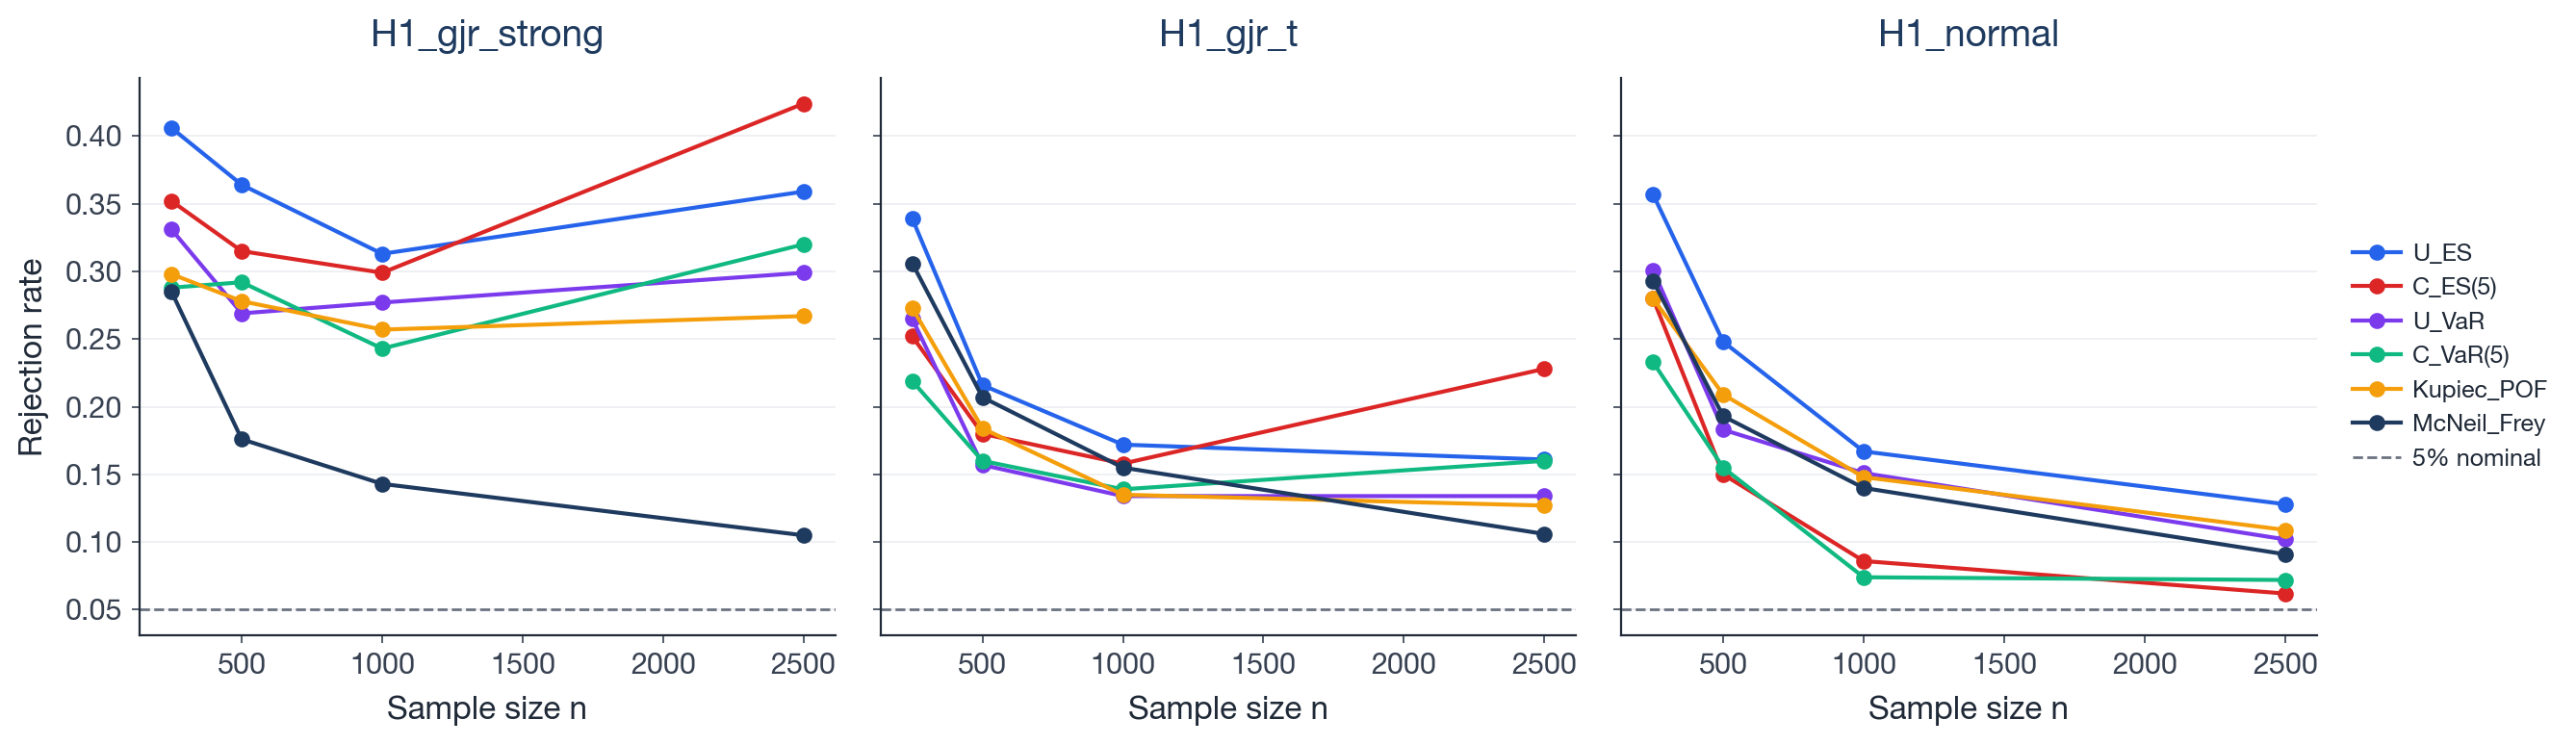

In [4]:
power_summary = summary[summary["scenario"].isin(["H1_gjr_t", "H1_gjr_strong", "H1_normal"])]
fig = figures.plot_power_curves(
    power_summary,
    key_tests,
    save_to=ASSETS_FIG / "03_power_curves.png",
)
plt.show()

## Reject rate at n = 1000

A snapshot of the empirical rejection rate at the largest sample size for which we have all tests.

In [5]:
snap = (
    summary[summary["n"] == 1000]
    .pivot_table(index="test", columns="scenario", values="rejection_rate")
    .round(2)
)
snap = snap.reindex(
    [
        t
        for t in [
            "U_ES",
            "C_ES(5)",
            "MU_ES",
            "MC_ES(5)",
            "U_VaR",
            "C_VaR(5)",
            "AS_Z1",
            "AS_Z2",
            "McNeil_Frey",
            "Kupiec_POF",
            "Christoffersen_CCI",
            "Christoffersen_CC",
            "KLM_multinomial(4)",
        ]
        if t in snap.index
    ]
)
display(snap)

scenario,H0_garch_t,H1_gjr_strong,H1_gjr_t,H1_normal
test,,,,
U_ES,0.16,0.31,0.17,0.17
C_ES(5),0.08,0.30,0.16,0.09
U_VaR,0.14,0.28,0.13,0.15
C_VaR(5),0.08,0.24,0.14,0.07
AS_Z1,0.12,0.12,0.10,0.07
AS_Z2,0.14,0.23,0.14,0.12
McNeil_Frey,0.16,0.14,0.16,0.14
Kupiec_POF,0.13,0.26,0.14,0.15
Christoffersen_CCI,0.04,0.10,0.05,0.04


## Discussion

**Snapshot at n=1000** (table above). This discussion references only what the snapshot displays; the full power curves for `n ∈ {250, 500, 1000, 2500}` are in the figures `03_size_under_h0.png` (CODE #5) and `03_power_curves.png` (CODE #7). The Acerbi-Szekely Z1 / Z2 p-values are parametric Monte-Carlo readings produced by the `StandardizedTSimulator` (`n_sim_power = 2000` draws per replication). The grid spans 4 scenarios × 4 sample sizes × 1,000 replications = 16,000 simulated paths, totalling 176,000 statistic/replication rows.

**Under H0_garch_t (correct specification).** `Christoffersen_CCI` (0.04), `C_ES(5)` and `C_VaR(5)` (0.08) are within four percentage points of the nominal 5% size. The other tests overshoot: `U_ES` and `McNeil_Frey` at 0.16, `U_VaR` and `AS_Z2` at 0.14, `Kupiec_POF` and `KLM_multinomial(4)` at 0.13, `AS_Z1` and `Christoffersen_CC` at 0.12. The asymptotic N(0,1) and chi-squared distributions of Du-Escanciano (2017) eq. (5)-(6) and Kupiec (1995) predict convergence to 5% as `n` grows; at `n=1000` that convergence has not yet been reached for the marginal-coverage tests.

**Under H1_gjr_t (γ=0.15, moderate leverage).** All rejection rates stay below 20%: `U_ES` 0.17, `C_ES(5)` 0.16, `McNeil_Frey` 0.16, `KLM_multinomial(4)` 0.15, `AS_Z2` 0.14, `C_VaR(5)` 0.14, `Kupiec_POF` 0.14, `Christoffersen_CC` 0.13, `U_VaR` 0.13, `AS_Z1` 0.10, `Christoffersen_CCI` 0.05. At this leverage intensity, several tests (`AS_Z1`, `Christoffersen_CCI`) sit at or below their H0 size.

**Under H1_gjr_strong (γ=0.25, strong leverage).** The conditional Box-Pierce statistics on cumulative violations lead the power ranking: `U_ES` 0.31, `C_ES(5)` 0.30, `U_VaR` 0.28, `Kupiec_POF` and `Christoffersen_CC` 0.26, `KLM_multinomial(4)` 0.25, `C_VaR(5)` 0.24, `AS_Z2` 0.23. Net power (rejection rate at H1 minus rejection rate at H0): +22 pp for `C_ES(5)`, +16 pp for `C_VaR(5)`, +15 pp for `U_ES`, +14 pp for `U_VaR` and `Christoffersen_CC`, +13 pp for `Kupiec_POF`, +12 pp for `KLM_multinomial(4)`, +9 pp for `AS_Z2`, +6 pp for `Christoffersen_CCI`, 0 pp for `AS_Z1`, −2 pp for `McNeil_Frey`.

`AS_Z2` is the most active *ES-specific* test under leverage: it tracks both the *frequency* and the *magnitude* of violations and gains +9 pp net of H0 size. `AS_Z1` (0.12 at H1, 0.12 at H0) gains nothing — it normalises by the empirical violation set, so it is blind to whether violations are *too numerous*, only to whether the *severity given a violation* exceeds ES. `McNeil_Frey` (0.14 vs 0.16 H0) actually moves slightly *below* its H0 size at this leverage intensity.

**Under H1_normal (Gaussian innovations instead of Student-t).** The rejection rates hug the H0 size (`U_ES` 0.17, `Christoffersen_CCI` 0.04, `Kupiec_POF` 0.15, `McNeil_Frey` 0.14, `AS_Z1` 0.07, `AS_Z2` 0.12, `KLM_multinomial(4)` 0.13, `Christoffersen_CC` 0.11). At `n=1000`, the mismatch between the Gaussian tail and the Student-t tail predicted by the fitted model is not pronounced enough in the PIT for any of the `u_t`-based tests to detect: the frequency and magnitude of violations under a Normal DGP at typical equity-return scales stays close to what a correctly specified t would produce.

**Theoretical misspecification vs empirical detection.** The fitted model is symmetric `AR(1)-GARCH(1,1)-t`; under `H1_gjr_*` it is misspecified relative to the leverage component of the DGP, by construction. The observed rejection rate measures the empirical sensitivity of the battery to this misspecification, which depends jointly on the leverage intensity (`gamma`) and the sample size. The `H1_gjr_t → H1_gjr_strong` transition quantifies this sensitivity at fixed `n=1000`. The headline pattern: the conditional Box-Pierce statistics on cumulative violations (`C_ES(5)`, `C_VaR(5)`) gain the most net power, followed by the marginal-coverage block (`U_ES`, `U_VaR`, `Christoffersen_CC`, `Kupiec_POF`, `KLM_multinomial(4)`) and then `AS_Z2`; the tests that condition on the empirical violation set (`AS_Z1`, `McNeil_Frey`) or only test independence (`Christoffersen_CCI`) gain little or nothing.